In [1]:
datasets = ['CUB', 'Derm7pt', 'RIVAL10']
use_dataset = datasets[2]

In [2]:
import os
import sys
import seaborn as sns
import matplotlib.pyplot as plt

notebook_dir = os.getcwd()
project_root_path = os.path.dirname(notebook_dir)
sys.path.insert(0, project_root_path)

from src.config import PROJECT_ROOT, CUB_CONFIG, DERM7PT_CONFIG, RIVAL10_CONFIG  # noqa: E402
import numpy as np  # noqa: E402

In [3]:
DATASET_PATH =  os.path.join(PROJECT_ROOT, 'output', use_dataset)
if use_dataset == 'CUB':
    config_dict = CUB_CONFIG
elif use_dataset == 'Derm7pt':
    config_dict = DERM7PT_CONFIG
else:
    config_dict = RIVAL10_CONFIG

In [4]:
num_concepts = config_dict['N_TRIMMED_CONCEPTS']
num_classes = config_dict['N_CLASSES']

# Get prototype and concept names

In [51]:
import json

def get_class_names(label_mappings_path):
    """
    Reads the label_mappings.json file to determine the correct order of class names
    as implicitly determined by scikit-learn's OneHotEncoder.
    """
    with open(label_mappings_path, 'r') as f:
        label_mappings = json.load(f)

    # The super-class is the first element in the value list (e.g., "truck" in ["truck", 0])
    super_classes = {mapping[0] for mapping in label_mappings.values()}

    # OneHotEncoder sorts the unique classes alphabetically to create the encoding
    sorted_class_names = sorted(list(super_classes))

    return sorted_class_names

# --- HOW TO USE IT ---
# Replace with the actual path to your file
label_mappings_file = os.path.join(PROJECT_ROOT, 'data', 'RIVAL10', 'meta', 'label_mappings.json')
class_names = get_class_names(label_mappings_file)

# This will print the list that maps an index to a class name
# e.g., class_names[0] is 'bird', class_names[1] is 'car', etc.
print(class_names)
# Expected output:
# ['bird', 'car', 'cat', 'deer', 'dog', 'equine', 'frog', 'plane', 'ship', 'truck']

['bird', 'car', 'cat', 'deer', 'dog', 'equine', 'frog', 'plane', 'ship', 'truck']


In [52]:

import pickle


def reconstruct_concept_list(project_root):
    """
    Scans all _attr_dict.pkl files in the RIVAL10 dataset to reconstruct
    the alphabetically sorted master list of concept names.
    """
    train_path = os.path.join(project_root, 'data', 'RIVAL10', 'train', 'ordinary')
    test_path = os.path.join(project_root, 'data', 'RIVAL10', 'test', 'ordinary')

    all_concept_names = set()

    print("Scanning directories to find all unique concepts...")

    # Scan both training and testing directories
    for dir_path in [train_path, test_path]:
        if not os.path.isdir(dir_path):
            print(f"Warning: Directory not found, skipping: {dir_path}")
            continue

        for filename in os.listdir(dir_path):
            if filename.endswith('_attr_dict.pkl'):
                file_path = os.path.join(dir_path, filename)
                with open(file_path, 'rb') as f:
                    try:
                        data = pickle.load(f)
                        # Add all concept names from this file to our set
                        all_concept_names.update(data.keys())
                    except Exception as e:
                        print(f"Error reading {filename}: {e}")

    # Sort the unique names alphabetically to get the final ordered list
    sorted_concepts = sorted(list(all_concept_names))

    print(f"\nFound {len(sorted_concepts)} unique concepts.")

    # This is the master list we need
    return sorted_concepts

# Run the reconstruction
concept_names = reconstruct_concept_list(PROJECT_ROOT)

# Print the final list to verify
print("\nReconstructed Concept Name List (Index -> Name):")
for i, name in enumerate(concept_names):
    print(f"{i}: {name}")

Scanning directories to find all unique concepts...

Found 19 unique concepts.

Reconstructed Concept Name List (Index -> Name):
0: beak
1: colored-eyes
2: ears
3: entire-object
4: floppy-ears
5: hairy
6: horns
7: long
8: long-snout
9: mane
10: metallic
11: patterned
12: rectangular
13: tail
14: tall
15: text
16: wet
17: wheels
18: wings


# Load and Transform Data

In [5]:
prototypes = np.load(os.path.join(DATASET_PATH, 'learned_prototypes.npy'))

In [6]:
prototypes

array([[0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
        0., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0.,
        0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 1., 0., 0., 0., 0.,
        0., 1.],
       [1., 0., 0., 0., 1., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
        0., 1.],
       [1., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
        0., 0.],
       [1., 0., 0., 0., 0., 0., 1., 0., 1., 1., 0., 1., 0., 0., 0., 0.,
        0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
        0., 1.],
       [0., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1.,
        1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.,
        1., 0.],
       [0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 1.,
        1., 0.]], dtype=float32)

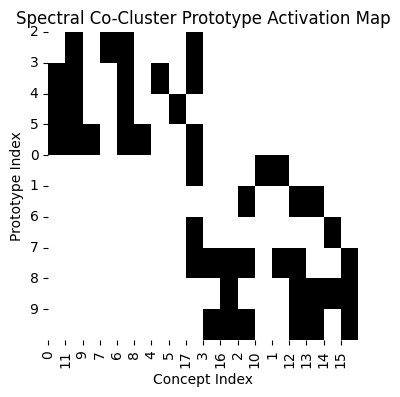

In [8]:
from sklearn.cluster import SpectralCoclustering


row_sums = prototypes.sum(axis=1)
col_sums = prototypes.sum(axis=0)

prototypes[row_sums == 0, :] = 1e-10
prototypes[:, col_sums == 0] = 1e-10

if use_dataset=='CUB':
    k = 3
else:
    k=2

model = SpectralCoclustering(n_clusters=k, random_state=0)
model.fit(prototypes)

row_perm = np.argsort(model.row_labels_)
col_perm = np.argsort(model.column_labels_)

# Apply permutation to matrix
spectral_prototypes = prototypes[row_perm][:, col_perm]

# Plot with correct original indices as ticks
plt.figure(figsize=(4,4))
sns.heatmap(spectral_prototypes, cmap='Greys', cbar=False)

plt.xlabel("Concept Index")
plt.ylabel("Prototype Index")

# Set ticks to original indices (after reordering)
plt.yticks(ticks=np.arange(len(row_perm)), labels=row_perm, rotation=0)
plt.xticks(ticks=np.arange(len(col_perm)), labels=col_perm, rotation=90)

plt.title("Spectral Co-Cluster Prototype Activation Map")
plt.show()

In [9]:
cluster_assignments = model.row_labels_

clusters_labels = {0: np.array(np.where(cluster_assignments==0)),
                    1: np.array(np.where(cluster_assignments==1)),
                    2: np.array(np.where(cluster_assignments==2))
                    }

clusters_prototypes = {0: prototypes[np.where(cluster_assignments==0)],
                        1: prototypes[np.where(cluster_assignments==1)],
                        2: prototypes[np.where(cluster_assignments==2)]
                        }

In [ ]:
import numpy as np
from collections import deque

class TreeNode:
    def __init__(self, prototypes, prototype_labels=None, concepts=None, parent=None):
        self.prototypes = prototypes
        # Ensure labels are a NumPy array for consistent, fast operations.
        self.prototype_labels = np.asarray(prototype_labels) if prototype_labels is not None else np.array([])
        self.concepts = concepts if concepts is not None else []
        self.children = []
        self.parent = parent
        self.is_leaf = False
        self.node_id = None
        # Internal attribute to cache all pure concepts for this node's group
        self._total_pure_concepts = set()

def build_concept_tree(prototypes, prototype_labels=None, max_leaf_size=1):
    if prototype_labels is None:
        prototype_labels = np.arange(len(prototypes))

    # Ensure a NumPy array is used from the start for labels.
    prototype_labels = np.asarray(prototype_labels)

    root = TreeNode(prototypes, prototype_labels)
    queue = deque([root])
    node_counter = 0

    while queue:
        current = queue.popleft()
        current.node_id = node_counter
        node_counter += 1

        total_prototypes = len(current.prototypes)
        if total_prototypes == 0:
            current.is_leaf = True
            continue

        concept_counts = np.sum(current.prototypes, axis=0)

        # --- REQUIREMENT 1: CONCEPT INHERITANCE LOGIC ---
        # 1. Calculate ALL concepts that are pure for this node's prototypes.
        my_total_pure_concepts = set(np.where(concept_counts == total_prototypes)[0])
        current._total_pure_concepts = my_total_pure_concepts  # Cache for its children

        # 2. Get the pure concepts from the parent (efficiently, from its cache).
        parent_pure_concepts = current.parent._total_pure_concepts if current.parent else set()

        # 3. This node's public `concepts` list should only contain what's new.
        new_concepts = my_total_pure_concepts - parent_pure_concepts
        current.concepts.extend(sorted(list(new_concepts)))

        # --- Leaf condition checks (no changes needed here) ---
        if total_prototypes <= max_leaf_size:
            current.is_leaf = True
            continue

        non_pure_concepts_mask = (concept_counts > 0) & (concept_counts < total_prototypes)
        if not np.any(non_pure_concepts_mask):
            current.is_leaf = True
            continue

        # --- Efficient Child Creation (no changes needed here) ---
        unassigned_mask = np.ones(total_prototypes, dtype=bool)
        remaining_concept_counts = concept_counts.copy()
        num_remaining_prototypes = total_prototypes

        while num_remaining_prototypes > 0:
            valid_mask = (remaining_concept_counts > 0) & non_pure_concepts_mask
            if not np.any(valid_mask):
                break

            valid_indices = np.where(valid_mask)[0]
            frequencies = remaining_concept_counts[valid_indices] / num_remaining_prototypes
            best_concept = valid_indices[np.argmax(frequencies)]

            child_mask = (current.prototypes[:, best_concept] == 1) & unassigned_mask
            num_child_prototypes = np.sum(child_mask)

            if num_child_prototypes == 0:
                remaining_concept_counts[best_concept] = 0
                continue

            child_prototypes = current.prototypes[child_mask]
            # The label propagation logic remains the same, as it correctly filters labels.
            child_labels = current.prototype_labels[child_mask]

            child = TreeNode(child_prototypes, child_labels, [], current)
            current.children.append(child)
            queue.append(child)

            unassigned_mask[child_mask] = False
            child_concept_counts = np.sum(child_prototypes, axis=0)
            remaining_concept_counts -= child_concept_counts
            num_remaining_prototypes -= num_child_prototypes

        if num_remaining_prototypes > 0:
            final_child_prototypes = current.prototypes[unassigned_mask]
            final_child_labels = current.prototype_labels[unassigned_mask]
            child = TreeNode(final_child_prototypes, final_child_labels, [], current)
            current.children.append(child)
            queue.append(child)

    return root

In [11]:
def find_node_by_id(root, target_id):
    if root.node_id == target_id:
        return root
    for child in root.children:
        result = find_node_by_id(child, target_id)
        if result:
            return result
    return None

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches
import numpy as np
from collections import deque

# Helper classes and functions (Node, find_node_by_id) should be defined here as before.
class Node:
    def __init__(self, node_id, concepts=None, prototypes=None, prototype_labels=None, is_leaf=False, parent=None):
        self.node_id = node_id
        self.concepts = concepts if concepts is not None else []
        self.prototypes = prototypes if prototypes is not None else np.array([])
        self.prototype_labels = prototype_labels if prototype_labels is not None else np.array([])
        self.is_leaf = is_leaf
        self.parent = parent
        self.children = []

    def add_child(self, child_node):
        self.children.append(child_node)
        child_node.parent = self

def find_node_by_id(root, node_id):
    if not root:
        return None
    queue = deque([root])
    while queue:
        current = queue.popleft()
        if current.node_id == node_id:
            return current
        for child in current.children:
            queue.append(child)
    return None


def visualize_tree(
    root,
    class_names,
    concept_names,
    figsize=(16, 10),
    max_leaf_protos_to_display=3,
    max_internal_protos_to_display=4
):
    """
    Visualizes a concept tree with visually square nodes.
    """
    fig, ax = plt.subplots(figsize=figsize)
    ax.axis('off')

    if not root:
        print("Tree is empty.")
        plt.show()
        return

    # 1. Calculate node positions
    positions = {}
    def assign_positions(node, x=0, y=0, width=1):
        positions[node.node_id] = (x + width / 2, y)
        if node.children:
            child_width = width / len(node.children)
            for i, child in enumerate(node.children):
                child_x = x + i * child_width
                assign_positions(child, child_x, y - 1, child_width)
    assign_positions(root, 0, 0, 1)

    # Finalize axis limits *before* calculating the aspect ratio
    ax.set_xlim(-0.1, 1.1)
    ax.set_ylim(min(pos[1] for pos in positions.values()) - 0.5, 0.5)

    # --- NEW: Calculate aspect ratio to make nodes square ---
    # Get the ratio of y-span to x-span in data coordinates
    x_range = ax.get_xlim()[1] - ax.get_xlim()[0]
    y_range = ax.get_ylim()[1] - ax.get_ylim()[0]
    # Get the ratio of height to width in display coordinates (pixels)
    fig_width, fig_height = fig.get_size_inches()
    # This is the crucial ratio that corrects for the figure's shape
    aspect_ratio = (y_range / x_range) * (fig_width / fig_height)

    font_size = 11

    # 2. Draw nodes and edges
    for node_id, (x, y) in positions.items():
        node = find_node_by_id(root, node_id)
        if not node: continue

        # (The logic for label text generation is unchanged)
        if node.is_leaf:
            color = 'lightgreen'
            differentiating_concepts = set()
            parent = node.parent
            if parent and all(c.is_leaf for c in parent.children) and len(parent.children) > 1:
                my_concepts = set(np.where(node.prototypes[0] == 1)[0]) if node.prototypes.size > 0 else set()
                sibling_concepts_union = set()
                for sibling in parent.children:
                    if sibling is not node and sibling.prototypes.size > 0:
                        sibling_concepts_union.update(np.where(sibling.prototypes[0] == 1)[0])
                differentiating_concepts = my_concepts - sibling_concepts_union

            label_parts = []
            if differentiating_concepts:
                diff_list = sorted(list(differentiating_concepts))[:3]
                # Look up concept names using the indices
                diff_names = [concept_names[c] for c in diff_list]
                label_parts.append(", ".join(diff_names))

            if len(node.prototype_labels) <= max_leaf_protos_to_display:
                # Original line:
                label_parts.append(f"P{node.prototype_labels.tolist()[0]}: ")

                # New lines:
                # Use the indices in prototype_labels to look up names from the list
                proto_names = [class_names[i] for i in node.prototype_labels]
                label_parts.append(f"{proto_names[0].capitalize()}")

            else:
                label_parts.append(f"({len(node.prototypes)})")
            label = "\n".join(label_parts)
        else:
            color = 'lightblue'
            if node.concepts:
                max_concepts_in_label = 3
                # Look up concept names using the indices in node.concepts
                concept_name_list = [concept_names[c] for c in node.concepts]

                if len(concept_name_list) > max_concepts_in_label:
                    concepts_text = ", ".join(concept_name_list[:max_concepts_in_label])
                    concepts_str = f"{concepts_text}, ..."
                else:
                    concepts_str = ", ".join(concept_name_list)
            else:
                concepts_str = "Root"

            if len(node.prototypes) <= max_internal_protos_to_display:
                proto_str = f"P{node.prototype_labels.tolist()}"
            else:
                proto_str = f"({len(node.prototypes)})"
            label = f"{concepts_str}\n{proto_str}"

        # --- MODIFICATION: Set box size using the calculated aspect ratio ---
        default_box_height = 0.4
        default_box_width = default_box_height / aspect_ratio
        font_size = 11

        # Measure text size
        renderer = fig.canvas.get_renderer()
        text_obj = ax.text(0, 0, label, fontsize=font_size, weight='bold')
        bbox = text_obj.get_window_extent(renderer=renderer)
        text_width_disp = bbox.width / fig.dpi  # inches

        # Convert display width to data coordinates
        disp_to_data = x_range / fig_width
        required_box_width = text_width_disp * disp_to_data + 0.02  # 0.02 for padding

        box_width = max(default_box_width, required_box_width)
        box_height = default_box_height

        # Remove the temporary text object
        text_obj.remove()

        # Draw the node box and text
        rect = Rectangle((x - box_width / 2, y - box_height / 2), box_width, box_height,
                         facecolor=color, edgecolor='black', linewidth=1.5, zorder=3)
        ax.add_patch(rect)
        ax.text(x, y, label, ha='center', va='center', fontsize=font_size, weight='bold', zorder=4)

        # Draw clean edges to children
        for child in node.children:
            child_x, child_y = positions[child.node_id]
            ax.plot([x, child_x], [y - box_height / 2, child_y + box_height / 2], 'k-', linewidth=1, zorder=2)

    # 3. Finalize plot appearance
    ax.set_aspect('auto') # Explicitly keep auto aspect
    # ax.set_title('Concept Tree Visualization', fontsize=20, weight='bold', pad=20)

    leaf_patch = mpatches.Patch(color='lightgreen', label='Leaf Node', ec='black')
    internal_patch = mpatches.Patch(color='lightblue', label='Internal Node', ec='black')
    ax.legend(handles=[internal_patch, leaf_patch], loc='upper right', frameon=False, fontsize=12)

    plt.tight_layout()
    plot_dir = os.path.join(PROJECT_ROOT, 'output', 'plots', 'explanation')
    os.makedirs(plot_dir, exist_ok=True)
    plt.savefig(os.path.join(plot_dir, f'{use_dataset}_concept_tree.png'), dpi=600, bbox_inches='tight')

    plt.show()

In [48]:
import plotly.graph_objects as go
import numpy as np

def visualize_tree_plotly(
    root,
    figsize=(1080,720),
    max_leaf_protos_to_display=3,
    max_internal_protos_to_display=4 # CHANGE 1: New parameter
):
    if not root:
        print("Tree is empty.")
        return

    # --- 1. Layout Algorithm (Unchanged) ---
    positions = {}

    def set_depths(node, depth=0):
        node.depth = depth
        for child in node.children:
            set_depths(child, depth + 1)

    def assign_and_center_positions(node, leaf_counter=[0]):
        if not node.children:
            positions[node.node_id] = (leaf_counter[0], -node.depth)
            leaf_counter[0] += 1
        else:
            for child in node.children:
                assign_and_center_positions(child, leaf_counter)
            first_child_x = positions[node.children[0].node_id][0]
            last_child_x = positions[node.children[-1].node_id][0]
            parent_x = (first_child_x + last_child_x) / 2
            positions[node.node_id] = (parent_x, -node.depth)

    set_depths(root)
    assign_and_center_positions(root)

    # --- 2. Prepare data for Plotly traces ---
    edge_x, edge_y, node_x, node_y = [], [], [], []
    node_colors, node_hover_text, annotations = [], [], []

    queue = deque([root])
    visited = {root.node_id}

    while queue:
        node = queue.popleft()
        x, y = positions[node.node_id]
        node_x.append(x)
        node_y.append(y)

        if node.is_leaf:
            color = 'lightgreen'

            # ### CHANGE 2 & 3: NEW LOGIC FOR LEAF NODES ###

            # --- Part A: Calculate differentiating and inherited concepts ---
            inherited_concepts = set()
            current = node.parent
            while current:
                inherited_concepts.update(current.concepts)
                current = current.parent

            differentiating_concepts = set()
            parent = node.parent
            if parent and all(child.is_leaf for child in parent.children) and len(parent.children) > 1:
                my_concepts = set(np.where(node.prototypes[0] == 1)[0])
                sibling_concepts_union = set()
                for sibling in parent.children:
                    if sibling is not node:
                        sibling_concepts_union.update(np.where(sibling.prototypes[0] == 1)[0])
                differentiating_concepts = my_concepts - sibling_concepts_union

            # --- Part B: Create the node label ---
            label_parts = []

            # Add up to 3 differentiating concepts to the label (without "D:")
            if differentiating_concepts:
                diff_list = sorted(list(differentiating_concepts))[:2]
                label_parts.append(", ".join(f"C{c}" for c in diff_list))

            # Add prototype IDs or count to the label
            if len(node.prototype_labels) <= max_leaf_protos_to_display:
                label_parts.append(f"P{node.prototype_labels.tolist()}")
            else:
                label_parts.append(f"({len(node.prototypes)})")

            label = "<br>".join(label_parts)

            # --- Part C: Create the unified hover text ---
            full_concept_set = inherited_concepts.union(differentiating_concepts)
            full_concepts_str = ", ".join(sorted([f"C{int(c)}" for c in full_concept_set])) or "None"

            hover_text = (f"<b>Leaf Node ID:</b> {node.node_id}<br>"
                          f"<b>Prototype Label(s):</b> {node.prototype_labels.tolist()}<br>"
                          f"<b>Full Concepts:</b> {full_concepts_str}")

        else: # Internal node
            color = 'lightblue'

            # ### CHANGE 1: NEW LOGIC FOR INTERNAL NODES ###

            # --- Part A: Create the concept line of the label ---
            if node.concepts:
                max_concepts_in_label = 3
                if len(node.concepts) > max_concepts_in_label:
                    concepts_text = ", ".join(f"C{c}" for c in node.concepts[:max_concepts_in_label])
                    concepts_str = f"{concepts_text}, ..."
                else:
                    concepts_str = ", ".join(f"C{c}" for c in node.concepts)
            else:
                concepts_str = "Root"

            # --- Part B: Create the prototype line of the label (ID list or count) ---
            if len(node.prototypes) <= max_internal_protos_to_display:
                proto_str = f"P{node.prototype_labels.tolist()}"
            else:
                proto_str = f"({len(node.prototypes)})"

            label = f"{concepts_str}<br>{proto_str}"

            # --- Part C: Hover text for internal nodes (unchanged) ---
            clean_concepts_list = [int(c) for c in node.concepts] if node.concepts else 'None'
            hover_text = (f"<b>Internal Node ID:</b> {node.node_id}<br>"
                        f"<b>New Concepts:</b> {clean_concepts_list}<br>"
                        f"<b>Prototype Count:</b> {len(node.prototypes)}")

        node_colors.append(color)
        node_hover_text.append(hover_text)
        annotations.append(dict(
                x=x,
                y=y,
                text=label,
                showarrow=False,
                font=dict(color='black', size=14),
                xanchor='center',
                yanchor='middle'
            ))

        for child in node.children:
            if child.node_id not in visited:
                child_x, child_y = positions[child.node_id]
                edge_x.extend([x, child_x, None])
                edge_y.extend([y, child_y, None])
                queue.append(child)
                visited.add(child.node_id)

    # --- 3. & 4. Create Traces and Assemble Figure (Unchanged) ---
    edge_trace = go.Scatter(x=edge_x, y=edge_y, line=dict(width=1, color='black'), hoverinfo='none', mode='lines')
    node_trace = go.Scatter(
        x=node_x, y=node_y,
        mode='markers',
        hoverinfo='text',
        hovertext=node_hover_text,
        marker=dict(
            symbol='square',
            color=node_colors,
            size=70,
            line=dict(width=1, color='black')
        )
    )
    fig = go.Figure(data=[edge_trace, node_trace])
    legend_annotations = [go.layout.Annotation(x=0.98, y=0.98, xref="paper", yref="paper", text="Internal Node", showarrow=False, xanchor='right', yanchor='top'), go.layout.Annotation(x=0.98, y=0.94, xref="paper", yref="paper", text="Leaf Node", showarrow=False, xanchor='right', yanchor='top')]
    legend_shapes = [go.layout.Shape(type="rect", xref="paper", yref="paper", x0=1.0, y0=0.96, x1=1.02, y1=0.98, fillcolor='lightblue', line=dict(color='black')), go.layout.Shape(type="rect", xref="paper", yref="paper", x0=1.0, y0=0.92, x1=1.02, y1=0.94, fillcolor='lightgreen', line=dict(color='black'))]
    fig.update_layout(title=dict(text='<b>Concept Tree Visualization (Interactive)</b>', x=0.5, font=dict(size=16)), width=figsize[0], height=figsize[1], showlegend=False, annotations=annotations + legend_annotations, shapes=legend_shapes, xaxis=dict(showgrid=False, zeroline=False, showticklabels=False, visible=False), yaxis=dict(showgrid=False, zeroline=False, showticklabels=False, visible=False), plot_bgcolor='white', margin=dict(l=20, r=40, b=20, t=40), hovermode='closest')

    fig.write_html("tree_visualization.html")

    fig.show()

In [49]:
idx = 0
tree = build_concept_tree(clusters_prototypes[idx], clusters_labels[idx][0], max_leaf_size=1)

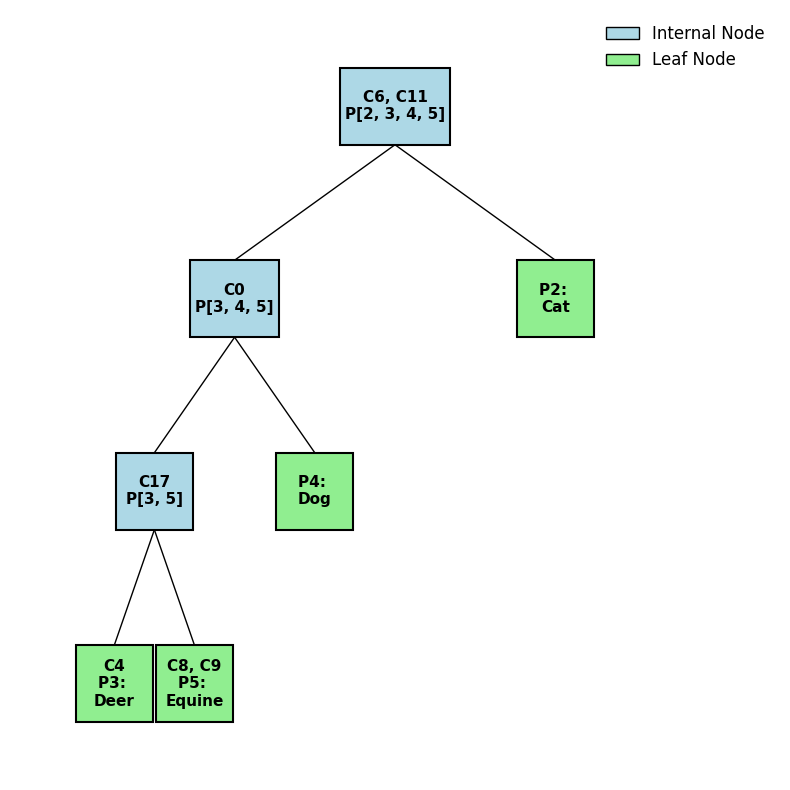

In [50]:
visualize_tree(tree, class_names, figsize=(8, 8))

In [22]:
visualize_tree_plotly(tree)